In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


!Usuniemy kolumne ID

In [4]:
df = df.drop(columns=['CustomerID'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Genre                   200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [6]:
!Rozklad wieku

'Rozklad' is not recognized as an internal or external command,
operable program or batch file.


<Axes: xlabel='Age', ylabel='Count'>

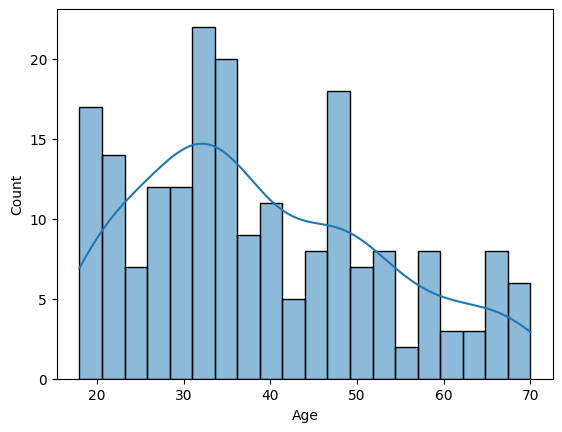

In [7]:
sns.histplot(df['Age'], bins=20, kde=True)

!Scatter plot

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

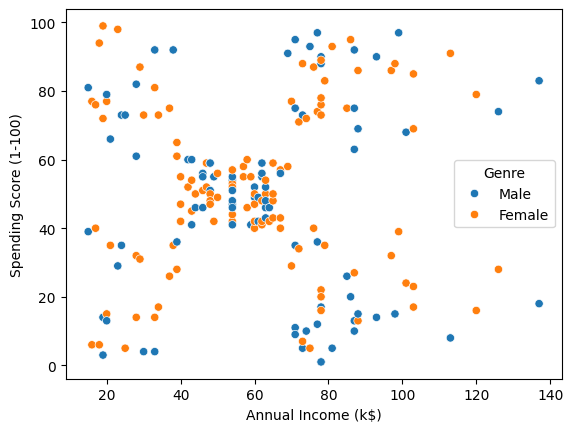

In [8]:
sns.scatterplot(data=df, 
                x='Annual Income (k$)', 
                y='Spending Score (1-100)',
                hue='Genre')

In [9]:
encoder = LabelEncoder()
df["Genre"] = encoder.fit_transform(df['Genre'])
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


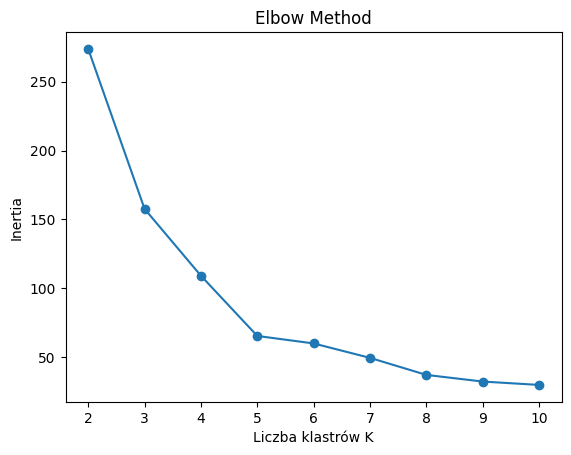

In [10]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, 'o-')
plt.title('Elbow Method')
plt.xlabel('Liczba klastrów K')
plt.ylabel('Inertia')
plt.show()

!Metoda lokcia wskazuje na 5 grup
Inertia mała = punkty blisko środka = klastry zwarte = dobry model
Inertia duża = punkty daleko od środka = klastry rozrzucone = słaby model

In [11]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster_bez_plci'] = kmeans.fit_predict(X_scaled)

print(df.groupby('Cluster_bez_plci')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))

                  Annual Income (k$)  Spending Score (1-100)
Cluster_bez_plci                                            
0                               55.3                    49.5
1                               86.5                    82.1
2                               25.7                    79.4
3                               88.2                    17.1
4                               26.3                    20.9


In [12]:

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster z  wiekiem'] = kmeans.fit_predict(X_scaled)

print(df.groupby('Cluster z  wiekiem')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))

                     Age  Annual Income (k$)  Spending Score (1-100)
Cluster z  wiekiem                                                  
0                   55.3                47.6                    41.7
1                   32.9                86.1                    81.5
2                   25.8                26.1                    74.8
3                   26.7                54.3                    40.9
4                   44.4                89.8                    18.5


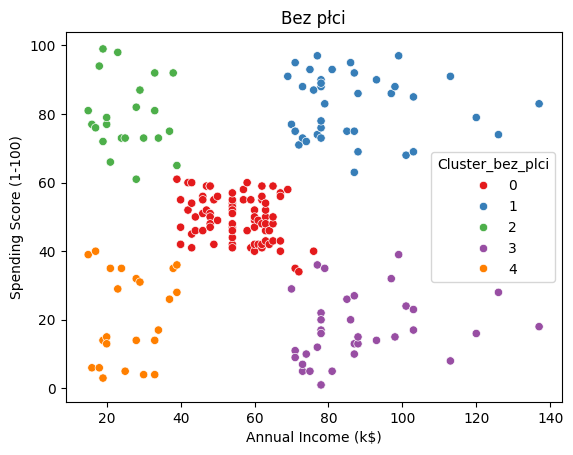

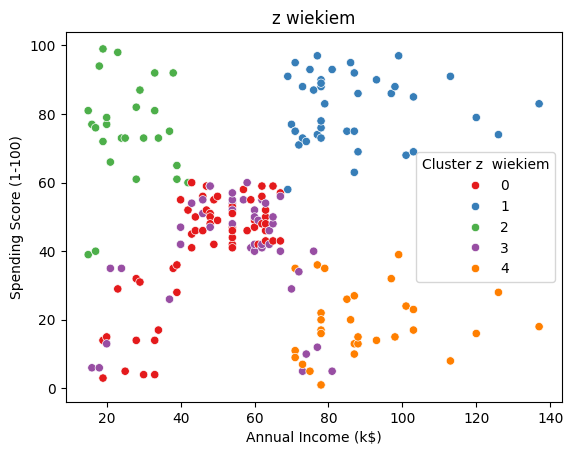

In [13]:
# bez płci
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster_bez_plci', palette='Set1')
plt.title('Bez płci')
plt.show()

# z wiekiem
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster z  wiekiem', palette='Set1')
plt.title('z wiekiem')
plt.show()

In [14]:
print(df.groupby('Cluster z  wiekiem')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))


                     Age  Annual Income (k$)  Spending Score (1-100)
Cluster z  wiekiem                                                  
0                   55.3                47.6                    41.7
1                   32.9                86.1                    81.5
2                   25.8                26.1                    74.8
3                   26.7                54.3                    40.9
4                   44.4                89.8                    18.5


In [15]:
print(df.groupby('Cluster_bez_plci')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))


                  Annual Income (k$)  Spending Score (1-100)
Cluster_bez_plci                                            
0                               55.3                    49.5
1                               86.5                    82.1
2                               25.7                    79.4
3                               88.2                    17.1
4                               26.3                    20.9


!Dodając wiek scatter plot 2D staje się mylący – klastry "mieszają się" bo wiek jest niewidoczny na osiach Income/Spending. PCA redukuje 3 wymiary do 2 zachowując jak najwięcej informacji, co pozwala poprawnie zwizualizować podział.

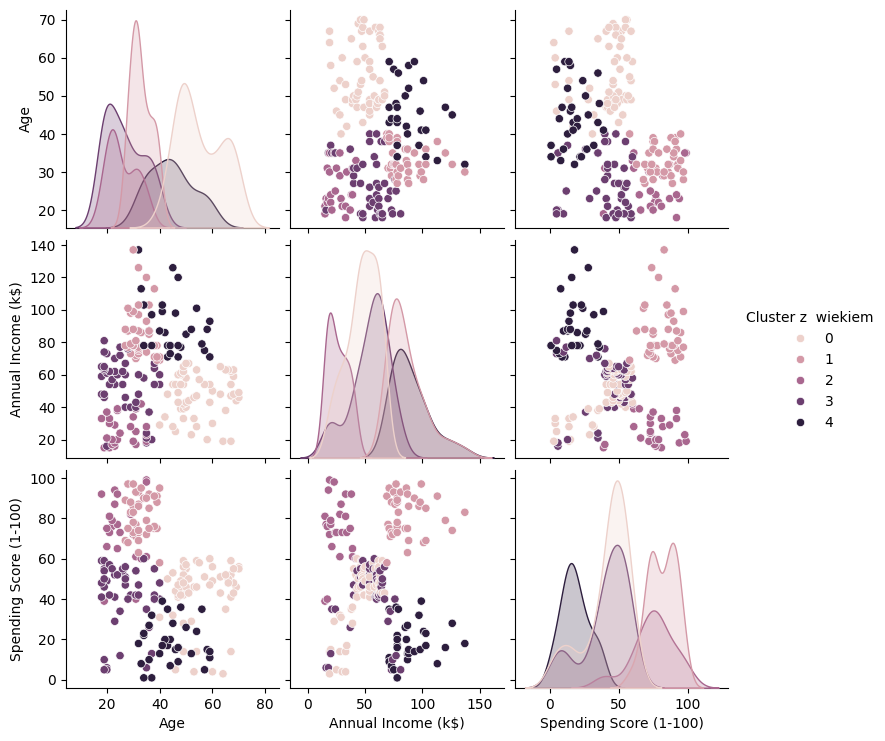

In [16]:
# Pairplot
sns.pairplot(df, vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], hue='Cluster z  wiekiem')
plt.show()

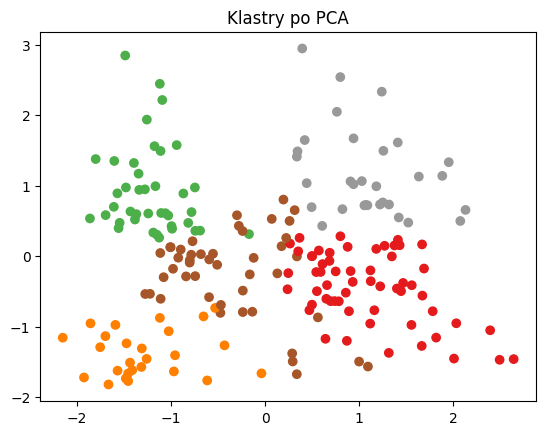

In [17]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X_scaled = StandardScaler().fit_transform(X)

# Redukcja do 2 wymiarów
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Klastry
labels = KMeans(n_clusters=5, random_state=42).fit_predict(X_scaled)

# Wykres
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1')
plt.title('Klastry po PCA')
plt.show()

!Zielony i pomarańczowy → bardzo wyraźnie oddzielone od reszty ✅

!Brązowy → rozrzucony między innymi grupami ⚠️

!Szary i czerwony → trochę się nakładają ⚠️